ROLL NUMBER:24F-AI-111

NAME:NIMRA IFTIKHAR

TOPIC:HOUSE PREDICTION

(1460, 81)
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008  

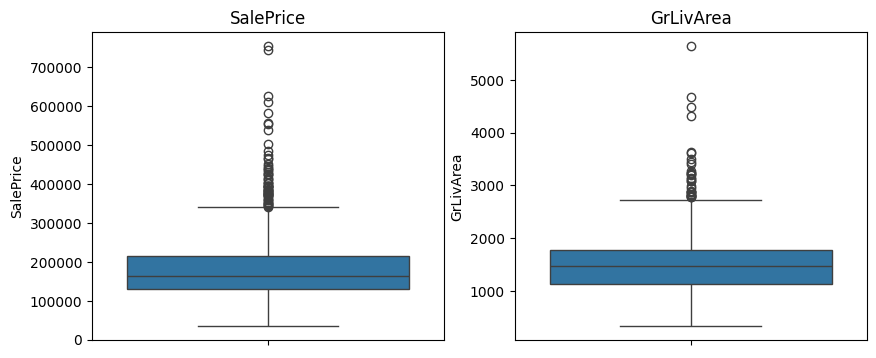

In [137]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, confusion_matrix
# loading the dataset
df = pd.read_csv("train.csv")
print(df.shape)
print(df.head())
print(df.describe())
#from this we will see missing value and do sum of it
print(df.isnull().sum())
#we have to fill those null value with median so we do this
df = df.fillna(df.median(numeric_only=True))
#checking outlier using graph(box plot)
plt.figure(figsize=(10, 4))
# making the first box plot for SalePrice
plt.subplot(1, 2, 1)
sns.boxplot(y=df["SalePrice"])
plt.title("SalePrice")
plt.subplot(1, 2, 2)
sns.boxplot(y=df["GrLivArea"])
plt.title("GrLivArea")
plt.show()


### Loading and Checking Data

First, we load the `train.csv` file and check the basic information of our dataset, like its size, first few rows, statistics and missing values. After that, we fill the missing numerical values with the median.


In [138]:
# loading the data and checking it
df = pd.read_csv("train.csv")
print(df.shape)
print(df.head())
print(df.describe())
print(df.isnull().sum())
df = df.fillna(df.median(numeric_only=True))

(1460, 81)
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008  

### Checking Outliers

i am  using box plots to check if there are any outliers in `SalePrice` and `GrLivArea`. This helps me to identify unusual values in our data before moving.


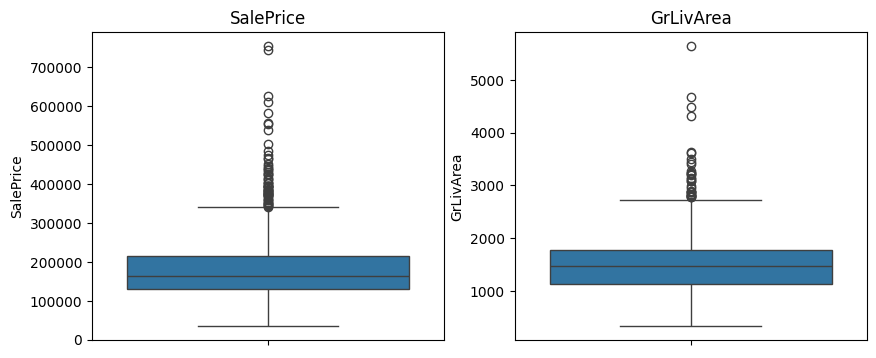

In [139]:
#checking outlier using graph(box plot)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.boxplot(y=df["SalePrice"])
plt.title("SalePrice")
plt.subplot(1, 2, 2)
sns.boxplot(y=df["GrLivArea"])
plt.title("GrLivArea")
plt.show()

In [140]:
# removing outliers with IQR method because in linear regression is so sensitive for outliers
def remove_outliers(data, col):
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    return data[(data[col] >= low) & (data[col] <= high)]

print("before:", len(df))
df = remove_outliers(df, "SalePrice")
df = remove_outliers(df, "GrLivArea")
print("after:", len(df))

before: 1460
after: 1378


###

Here i am dividing the houses into three price categories: **Low, Medium, and High**as given in question.i use `qcut` so that each category has almost the same number of houses.


In [141]:
# making the price category (Low / Medium / High)
df["PriceCategory"] = pd.qcut(df["SalePrice"], 3, labels=["Low", "Medium", "High"])
print(df["PriceCategory"].value_counts())


PriceCategory
Low       464
High      459
Medium    455
Name: count, dtype: int64


### 

Here i selected some important numerical columns and checking their correlation with `SalePrice`. The bar chart helps us see which features have a stronger or weaker relationship with the house price.


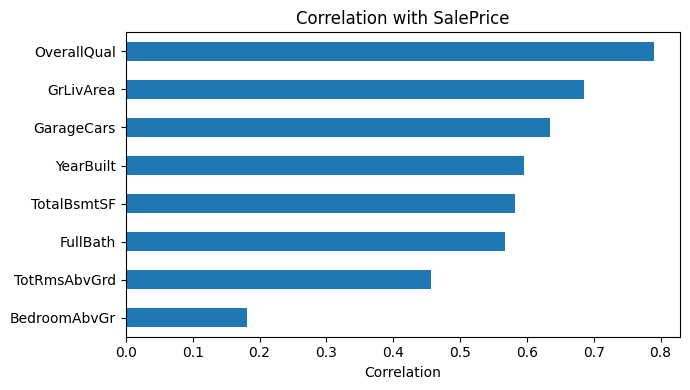

In [142]:
# using only my selected numeric columns so the chart stays readable
num_cols = ["GrLivArea", "OverallQual", "TotalBsmtSF", "GarageCars", "YearBuilt",
            "FullBath", "BedroomAbvGr", "TotRmsAbvGrd", "SalePrice"]
corr = df[num_cols].corr()
corr["SalePrice"].drop("SalePrice").sort_values().plot(kind="barh", figsize=(7, 4))
plt.title("Correlation with SalePrice")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()

### 

Here i convert the text columns like `Neighborhood` into numbers using one-hot encoding, then split the data into **training and testing sets**. After that i scale the features so the numerical values are on a similar scale before training the models.


In [143]:
# neighborhood is text so converting it with one hot encoding
X = pd.get_dummies(df.drop(columns=["SalePrice", "PriceCategory"]), drop_first=True)
y_price = df["SalePrice"]
y_cat = df["PriceCategory"]

# train test split 
X_train, X_test, yp_train, yp_test, yc_train, yc_test = train_test_split(
    X, y_price, y_cat, test_size=0.3, random_state=42)

# feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

###

Here i train a Linear Regressionmodel to predict house prices and check its performance using R² and RMSE. Then i make a graph to compare the actual prices with the predicted prices and see how well how my model is performing


R2 score: 0.88
RMSE: 19304


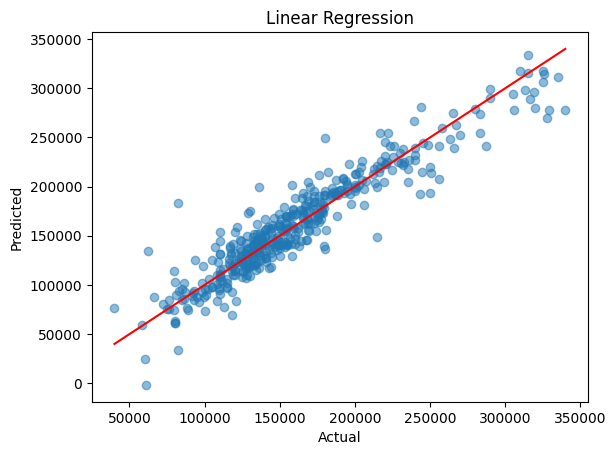

In [144]:
lr = LinearRegression()
lr.fit(X_train, yp_train)
price_pred = lr.predict(X_test)

r2 = r2_score(yp_test, price_pred)
rmse = np.sqrt(mean_squared_error(yp_test, price_pred))
print("R2 score:", round(r2, 3))
print("RMSE:", round(rmse))

# actual vs predicted
plt.scatter(yp_test, price_pred, alpha=0.5)
plt.plot([yp_test.min(), yp_test.max()], [yp_test.min(), yp_test.max()], color="red")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression")
plt.show()

### 

Here I use Random Forest and SVM to classify the houses into Low, Medium, and High price categories. I am checking the accuracy of both models to see which one performs better.


In [145]:
# random forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, yc_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(yc_test, rf_pred)
print("Random Forest accuracy:", round(rf_acc, 3))

# svm
svm = SVC(kernel="rbf")
svm.fit(X_train, yc_train)
svm_pred = svm.predict(X_test)
svm_acc = accuracy_score(yc_test, svm_pred)
print("SVM accuracy:", round(svm_acc, 3))

Random Forest accuracy: 0.829
SVM accuracy: 0.809


### 
Here I am using confusion matrices to check the performance of both models for each price category. It helps me see how many houses were correctly and incorrectly classified as Low, Medium, or High.


C:\Users\hamza\AppData\Local\Temp\ipykernel_11448\4262833894.py:18: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


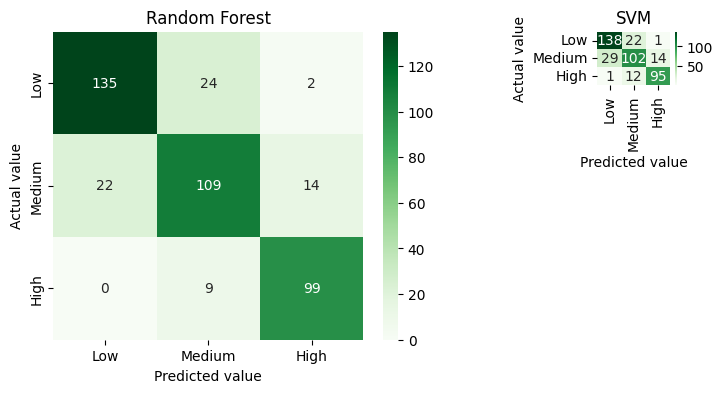

In [146]:
# confusion matrices)
labels = ["Low", "Medium", "High"]
plt.figure(figsize=(11, 4))

plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(yc_test, rf_pred, labels=labels), annot=True, fmt="d",
            cmap="Greens", xticklabels=labels, yticklabels=labels)
plt.title("Random Forest")
plt.xlabel("Predicted value")
plt.ylabel("Actual value")

plt.subplot(5, 8, 6)
sns.heatmap(confusion_matrix(yc_test, svm_pred, labels=labels), annot=True, fmt="d",
            cmap="Greens", xticklabels=labels, yticklabels=labels)
plt.title("SVM")
plt.xlabel("Predicted value")
plt.ylabel("Actual value")
plt.tight_layout()
plt.show()

### 
Here I am converting the Linear Regression price predictions into Low, Medium, and High categories so I can compare it with Random Forest and SVM. Then I am checking the accuracy of all three models to see which one performs better

In [147]:
# cutoffs from the training prices
low_cut = yp_train.quantile(0.33)
high_cut = yp_train.quantile(0.66)

def to_category(p):
    if p < low_cut:
        return "Low"
    elif p < high_cut:
        return "Medium"
    else:
        return "High"

lr_cat_pred = [to_category(p) for p in price_pred]
lr_acc = accuracy_score(yc_test, lr_cat_pred)

print("Linear Regression R2:", round(r2, 3))
print("Linear Regression (as category) accuracy:", round(lr_acc, 3))
print("Random Forest accuracy:", round(rf_acc, 3))
print("SVM accuracy:", round(svm_acc, 3))

Linear Regression R2: 0.88
Linear Regression (as category) accuracy: 0.836
Random Forest accuracy: 0.829
SVM accuracy: 0.809
